# Reproducing the CaryaData technical-validation QC pipeline (CPU)

**Paper:** *"An image dataset of Chinese hickory in natural orchards."* — **Scientific Data** 13:1047 (2026), DOI [10.1038/s41597-026-07407-9](https://doi.org/10.1038/s41597-026-07407-9).

**Scope — partial demonstration (Technical Validation, data-processing subsection):**

1. Run the authors' `image_qc.py` ROI quality screening on released *Scaled* images + YOLO labels and compare flagged-box counts with the paper-reported reference (203 flagged boxes).
2. Exercise the authors' `check_yolo_annotations_agreement.py` (IoU ≥ 0.9, Hungarian matching) on released annotations — as an **ADAPTED FORMAT-CONSISTENCY CHECK** if the two independent annotation rounds are not released.
3. Reproduce the authors' 6:2:2 stratified split logic (seed 42, rare class id 2) from `stratified_split.py` and compare membership with the released `CaryaData_YOLO` split.

**Out of scope:** YOLOv8n training benchmark (no paper-matched checkpoint is released), the detachment-force experiment, Raw-image processing.

**Provenance:** author code from GitHub `JiaNanefu/Carya-Data-code` @ `8fde217c7b69b0fef05e8c4d276525b78501a738`, also released as `code.zip` on Zenodo record **22054990**; data from Zenodo record **18661602** (paper-cited, images) and **22054990** (latest, labels). Author scripts are executed **unmodified** except hard-coded paths; all download/extraction/plotting glue is AI-generated for this notebook.

**日本語:** 本ノートブックは CaryaData 論文の Technical Validation のうち、画質スクリーニング(`image_qc.py`)・アノテーション整合性チェック(`check_yolo_annotations_agreement.py`)・層化データ分割(`stratified_split.py`)を公開データと著者コードで再現します。YOLOv8 学習ベンチマークは対象外です。

## Runtime & expectations

**Select Runtime → Change runtime type → CPU.** No GPU is used anywhere in this reproduction; a T4 is unnecessary.

| step | expected cost |
|---|---|
| dependency check | < 1 min |
| `code.zip` + `labels.zip` download | ~57 MB |
| *Scaled* image partial extraction from `CaryaData.zip` (7.8 GB archive, HTTP-Range) | ~0.3–0.5 GB fetched, a few minutes |
| QC screening of the matched Scaled images | seconds–minutes on CPU |
| whole notebook | ≈ 10–25 min |

If Zenodo refuses HTTP-Range requests, the notebook falls back to **one full streamed download of `CaryaData.zip` (7.8 GB, md5-verified)** — disclosed here so the cost is visible before "Run all".

**日本語:** GPU は不要です(ランタイムは CPU を選択)。全体で約 10〜25 分、ダウンロードは約 57 MB + 部分抽出 0.3〜0.5 GB(Range 非対応の場合は 7.8 GB 全体)です。

In [ ]:
%pip install -q opencv-python scikit-learn scipy pandas

import sys, cv2, numpy, pandas, sklearn, scipy, matplotlib
print("Python:", sys.version.split()[0])
for name, m in [("numpy", numpy), ("opencv-python", cv2), ("pandas", pandas),
                ("scikit-learn", sklearn), ("scipy", scipy), ("matplotlib", matplotlib)]:
    print(f"{name:15s} {m.__version__}")

Python: 3.13.16
numpy           2.1.3
opencv-python   5.0.0
pandas          2.2.3
scikit-learn    1.6.1
scipy           1.16.3
matplotlib      3.10.0


## 0. Reset the workspace so every run is fresh

All downloads, extraction and outputs live under `/content/carya`. Deleting it at the start guarantees that "Run all" exercises every download, checksum and extraction from scratch even on a reused kernel — no stale state can masquerade as a fresh validation.

**日本語:** `/content/carya` を最初に削除し、毎回完全に新規な状態でダウンロード・検証を行います。

In [ ]:
import shutil
shutil.rmtree("/content/carya", ignore_errors=True)
print("workspace reset: /content/carya removed")

workspace reset: /content/carya removed


## 1. Download the author code and label archives (pinned Zenodo record)

`labels.zip` (annotation release) and `code.zip` (author scripts) come from Zenodo record **22054990** (latest version, 2026-08-22); its `code.zip` is byte-identical (md5 `1971606a…`) to the paper-cited record 18661602. Sizes and MD5s below are taken from the record metadata and verified after download. Per the project data boundary, these bytes are only handled here inside Colab.

**日本語:** 著者コードとラベルを Zenodo レコード 22054990 から取得し、サイズと MD5 を検証します。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

BASE = Path("/content/carya")
ARCH = BASE / "archives"; ARCH.mkdir(parents=True, exist_ok=True)

# name: (url, expected_size_bytes, expected_md5) — from Zenodo record 22054990 file metadata
ZENODO_FILES = {
    "code.zip":   ("https://zenodo.org/api/records/22054990/files/code.zip/content",
                   56199143, "1971606ab51e47fb3633092a5b1d96aa"),
    "labels.zip": ("https://zenodo.org/api/records/22054990/files/labels.zip/content",
                   402715, "298da863634294b991dcf21d55ecc4d1"),
}

def fetch(name, url, expected_size, expected_md5):
    dest = ARCH / name
    if dest.exists() and dest.stat().st_size == expected_size:
        print(f"cached: {name}"); return dest
    tmp = dest.with_suffix(".part")
    with urllib.request.urlopen(url, timeout=600) as r, open(tmp, "wb") as f:
        while True:
            chunk = r.read(1 << 20)
            if not chunk:
                break
            f.write(chunk)
    data = tmp.read_bytes()
    md5 = hashlib.md5(data).hexdigest()
    assert len(data) == expected_size, f"{name}: size {len(data)} != {expected_size}"
    assert md5 == expected_md5, f"{name}: md5 {md5} != {expected_md5}"
    tmp.replace(dest)
    print(f"OK: {name}  {len(data):,} bytes  md5 {md5}")
    return dest

for name, (url, size, md5) in ZENODO_FILES.items():
    fetch(name, url, size, md5)

OK: code.zip  56,199,143 bytes  md5 1971606ab51e47fb3633092a5b1d96aa


OK: labels.zip  402,715 bytes  md5 298da863634294b991dcf21d55ecc4d1


## 2. Extract both archives and inspect their structure

Both ZIPs are CRC-tested and extracted under `/content/carya/extracted`. The directory summary below is printed from the actual release — the annotation layouts are discovered at runtime, not assumed.

**日本語:** 2 つの ZIP を展開し、実際のディレクトリ構成を表示します(レイアウトは実行時に確認)。

In [ ]:
import zipfile
from collections import Counter

EX = BASE / "extracted"
for name in ("code.zip", "labels.zip"):
    with zipfile.ZipFile(ARCH / name) as z:
        assert z.testzip() is None, f"corrupt member in {name}"
        z.extractall(EX / name.removesuffix(".zip"))

def summarize(root):
    stats = Counter()
    for p in Path(root).rglob("*"):
        if p.is_file():
            stats[str(p.relative_to(root).parent)] += 1
    for d, n in sorted(stats.items()):
        print(f"  {d}: {n} files")
    return stats

print("code.zip ->"); summarize(EX / "code")
print("labels.zip ->"); summarize(EX / "labels")

code.zip ->
  code: 9 files
  code/final_reason_analysis: 2 files
  code/final_reason_analysis/images: 158 files
labels.zip ->
  labels/test: 334 files
  labels/train: 996 files
  labels/val: 334 files


Counter({'labels/val': 334, 'labels/test': 334, 'labels/train': 996})

## 3. Discover the released annotation sets

The cell below classifies every `.txt` as a YOLO label (first line = class id + 4 floats) or other, collects VOC `.xml` files, and reads any `classes.txt`. The id→name mapping used later comes only from released files (`classes.txt`), with the author's own `voc_to_yolo.py` mapping (`maturity1→0, maturity2→1, maturity3→2, blurring→3`, commit `8fde217`) kept as a labeled fallback — never invented.

**日本語:** 公開ファイルから YOLO/VOC ラベルとクラス定義を検出します(推測しません)。

In [ ]:
def is_yolo_txt(p):
    try:
        first = p.read_text().splitlines()[0].split()
        if len(first) >= 5:
            int(first[0]); [float(x) for x in first[1:5]]
            return True
    except Exception:
        pass
    return False

yolo_files, other_txt = {}, []
for p in sorted(EX.rglob("*.txt")):
    if p.name == "classes.txt" or ".cache" in p.name:
        continue
    if is_yolo_txt(p):
        yolo_files.setdefault(p.stem, p)
    else:
        other_txt.append(p)
xml_files = {}
for p in sorted(EX.rglob("*.xml")):
    xml_files.setdefault(p.stem, p)
print(f"YOLO label files: {len(yolo_files)} | VOC xml files: {len(xml_files)} | other txt: {len(other_txt)}")
if other_txt[:5]:
    print("other txt examples:", [str(p.relative_to(EX)) for p in other_txt[:5]])

CLASS_NAMES = None
classes_files = sorted(EX.rglob("classes.txt"))
for cf in classes_files:
    print("---", cf); print(cf.read_text())
if classes_files:
    CLASS_NAMES = [ln.strip() for ln in classes_files[0].read_text().splitlines() if ln.strip()]
AUTHOR_FALLBACK = {0: "maturity1", 1: "maturity2", 2: "maturity3", 3: "blurring"}  # voc_to_yolo.py @ 8fde217
print("CLASS_NAMES from released classes.txt:", CLASS_NAMES)

YOLO label files: 1661 | VOC xml files: 0 | other txt: 1
other txt examples: ['code/code/final_reason_analysis/bad_quality_list.txt']
--- /content/carya/extracted/labels/labels/test/classes.txt
maturity0
maturity1
maturity2
maturity3
unknown

--- /content/carya/extracted/labels/labels/train/classes.txt
maturity0
maturity1
maturity2
maturity3
unknown

--- /content/carya/extracted/labels/labels/val/classes.txt
maturity0
maturity1
maturity2
maturity3
unknown

CLASS_NAMES from released classes.txt: ['maturity0', 'maturity1', 'maturity2', 'maturity3', 'unknown']


## 4. Open `CaryaData.zip` (7.8 GB) with HTTP-Range partial reads

The paper-cited dataset record 18661602 contains `CaryaData.zip` (7,811,208,829 bytes, md5 `e6daee8c…`). Instead of downloading everything, `HttpRangeFile` implements a seekable read-only view over HTTP Range requests so `zipfile` can read the central directory and extract only needed members; every extracted member is CRC-checked on read. If Range is refused, we fall back to one full streamed download with the recorded md5.

**日本語:** 7.8 GB のアーカイブ全体ではなく HTTP Range 部分読み取りで必要メンバーのみ取得します(非対応なら全体ダウンロード+MD5 検証)。

In [ ]:
import io, zipfile, urllib.request

CARYA_URL = "https://zenodo.org/api/records/18661602/files/CaryaData.zip/content"
CARYA_SIZE, CARYA_MD5 = 7811208829, "e6daee8c6b7f81847b81ca3d0f10189d"

class HttpRangeFile(io.IOBase):
    """Seekable read-only view of a remote file via HTTP Range requests."""
    def __init__(self, url, block=4 * 1024 * 1024, timeout=300):
        self.url, self.block, self.timeout = url, block, timeout
        self.bytes_fetched = 0
        req = urllib.request.Request(url, headers={"Range": "bytes=0-0"})
        with urllib.request.urlopen(req, timeout=timeout) as r:
            cr = r.headers.get("Content-Range")
            if cr is None:
                raise RuntimeError("server did not return Content-Range; Range unsupported")
            self.length = int(cr.rsplit("/", 1)[-1])
        self._pos, self._cs, self._cd = 0, None, b""
    def seekable(self): return True
    def tell(self): return self._pos
    def seek(self, off, whence=0):
        self._pos = self.length + off if whence == 2 else (self._pos + off if whence == 1 else off)
        return self._pos
    def _fetch(self, start, end):
        req = urllib.request.Request(self.url, headers={"Range": f"bytes={start}-{end}"})
        with urllib.request.urlopen(req, timeout=self.timeout) as r:
            if r.status != 206:
                raise IOError(f"HTTP {r.status} on range request")
            data = r.read()
        self.bytes_fetched += len(data)
        return data
    def readable(self): return True
    def read(self, n=-1):
        if self._pos >= self.length:
            return b""
        end = self.length - 1 if (n is None or n < 0) else min(self._pos + n - 1, self.length - 1)
        if end < self._pos:
            return b""
        out, s = [], self._pos
        while s <= end:
            blk = (s // self.block) * self.block
            if self._cs != blk:
                self._cd = self._fetch(blk, min(blk + self.block - 1, self.length - 1)); self._cs = blk
            off = s - blk
            if off >= len(self._cd):
                self._cd = self._fetch(s, end); self._cs = s; off = 0
                if not self._cd:
                    break
            take = min(len(self._cd) - off, end - s + 1)
            out.append(self._cd[off:off + take]); s += take
        data = b"".join(out); self._pos += len(data)
        return data

def full_download_fallback():
    dest = ARCH / "CaryaData.zip"
    if not (dest.exists() and dest.stat().st_size == CARYA_SIZE):
        tmp = dest.with_suffix(".part")
        with urllib.request.urlopen(CARYA_URL, timeout=1800) as r, open(tmp, "wb") as f:
            done = 0
            while True:
                chunk = r.read(1 << 22)
                if not chunk:
                    break
                f.write(chunk); done += len(chunk)
                if done % (200 << 20) < (1 << 22):
                    print(f"  {done/1e9:.2f} GB ...")
        assert tmp.stat().st_size == CARYA_SIZE, "size mismatch"
        tmp.replace(dest)
    h = hashlib.md5()
    with open(dest, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 22), b""):
            h.update(chunk)
    assert h.hexdigest() == CARYA_MD5, f"md5 mismatch: {h.hexdigest()}"
    print("full download verified:", CARYA_MD5)
    return zipfile.ZipFile(dest)

try:
    REMOTE = HttpRangeFile(CARYA_URL)
    print(f"Range requests OK; remote size {REMOTE.length:,} bytes")
    ZF = zipfile.ZipFile(REMOTE)
except Exception as e:
    print("Range failed -> full download fallback:", repr(e))
    ZF = full_download_fallback()
    REMOTE = None

Range requests OK; remote size 7,811,208,829 bytes


## 5. List the archive structure (central directory only)

Member names are read from the ZIP central directory — no payload bytes yet. We locate `Scaled/` images, `Raw/` images, `Metadata/` files, and any `CaryaData_YOLO/{train,val,test}` members. (Verified in a prior diagnostic run: the image archive does **not** contain the YOLO split — the released train/val/test membership lives in `labels.zip` and is used for the comparison in section 15.)

**日本語:** 中央ディレクトリからメンバー一覧だけを読み取り、Scaled/Metadata/YOLO 分割の構成を確認します(分割は `labels.zip` 側に収録)。

In [ ]:
from collections import Counter
from pathlib import Path

names = ZF.namelist()
print("total members:", len(names))
print("top level:", dict(Counter(n.split("/")[0] for n in names)))

def members_with(sub, exts):
    return [n for n in names if sub in n and n.lower().endswith(exts)]

scaled = members_with("/Scaled/", (".jpg", ".jpeg", ".png"))
raw = members_with("/Raw/", (".jpg", ".jpeg", ".png"))
meta = [n for n in names if "/Metadata/" in n and n.lower().endswith((".csv", ".json"))]
yolo_split = {sp: [n for n in names if f"/CaryaData_YOLO/{sp}/" in n] for sp in ("train", "val", "test")}
print(f"Scaled images: {len(scaled)} | Raw images: {len(raw)} | Metadata files: {len(meta)}")
for sp, ms in yolo_split.items():
    print(f"CaryaData_YOLO/{sp}: {len(ms)} members")
print("sample Scaled members:", scaled[:2])
print("Metadata members:", meta[:10])

total members: 9994
top level: {'CaryaData': 9994}
Scaled images: 1661 | Raw images: 1661 | Metadata files: 2
CaryaData_YOLO/train: 0 members
CaryaData_YOLO/val: 0 members
CaryaData_YOLO/test: 0 members
sample Scaled members: ['CaryaData/Scaled/images/0001.jpg', 'CaryaData/Scaled/images/0002.jpg']
Metadata members: ['CaryaData/Metadata/CaryaData_image_metadata.csv', 'CaryaData/Metadata/CaryaData_instance_metadata.csv']


## 6. Extract only the needed members

We extract (a) every *Scaled* image whose stem has a released YOLO label (the QC input set) and (b) small `Metadata` files (≤ 20 MB) for class-name cross-checks. `zf.read()` CRC-verifies each member; the total remotely fetched byte count is reported against the ≲ 0.5 GB soft target.

**日本語:** ラベル対応のある Scaled 画像と小さな Metadata のみを抽出します(CRC 検証付き)。

In [ ]:
import shutil, time

scaled_by_stem = {Path(n).stem: n for n in scaled}
label_stems = set(yolo_files)
targets = sorted(label_stems & set(scaled_by_stem))
print(f"labels {len(label_stems)} | Scaled images {len(scaled_by_stem)} | matched {len(targets)}")

IMG_DIR = BASE / "data" / "images"; IMG_DIR.mkdir(parents=True, exist_ok=True)
t0 = time.time()
for i, stem in enumerate(targets, 1):
    member = scaled_by_stem[stem]
    dest = IMG_DIR / Path(member).name
    if not dest.exists():
        with ZF.open(member) as f, open(dest, "wb") as o:
            shutil.copyfileobj(f, o)
    if i % 300 == 0 or i == len(targets):
        print(f"  {i}/{len(targets)} ({time.time()-t0:.0f}s)")
if REMOTE is not None:
    print(f"remote bytes fetched so far: {REMOTE.bytes_fetched/1e6:.1f} MB")
else:
    print("full-download fallback was used")

META_DIR = BASE / "data" / "metadata"; META_DIR.mkdir(parents=True, exist_ok=True)
for m in meta:
    if ZF.getinfo(m).file_size <= 20_000_000:
        with ZF.open(m) as f, open(META_DIR / Path(m).name, "wb") as o:
            shutil.copyfileobj(f, o)
print("metadata files extracted:", len(list(META_DIR.iterdir())))

labels 1661 | Scaled images 1661 | matched 1661


  300/1661 (126s)


  600/1661 (222s)


  900/1661 (368s)


  1200/1661 (504s)


  1500/1661 (627s)


  1661/1661 (668s)
remote bytes fetched so far: 601.2 MB


metadata files extracted: 2


## 7. Compatibility: mirror labels to the flat layout `image_qc.py` expects

`image_qc.py` resolves each image's label at `label_dir/<image's relative folder>/<stem>.txt`. Our extracted images sit flat in one directory, so we mirror every released YOLO label into one flat directory. This changes paths only — not the science.

**日本語:** `image_qc.py` のパス仕様に合わせてラベルをフラットにミラーします(科学的処理は不変)。

In [ ]:
LBL_MIRROR = BASE / "data" / "labels_mirror"; LBL_MIRROR.mkdir(parents=True, exist_ok=True)
n_new = 0
for stem in targets:
    dst = LBL_MIRROR / (stem + ".txt")
    if not dst.exists():
        shutil.copy2(yolo_files[stem], dst); n_new += 1
print(f"mirrored {n_new} label files ({len(list(LBL_MIRROR.glob('*.txt')))} total)")

mirrored 1661 label files (1661 total)


## 8. Input preview — released Scaled images with released YOLO ground truth

Two deterministic samples (sorted order: first stem containing rare class id 2, then the first stem without it) are shown with their released annotation boxes. Class ids are labeled with the mapping resolved from the released files above — these are ground-truth annotations, not predictions.

**日本語:** 公開 Scaled 画像と公開 YOLO 正解アノテーションを重ねて表示します(赤枠=正解、予測ではありません)。

id -> name mapping used for labels: {0: 'maturity0', 1: 'maturity1', 2: 'maturity2', 3: 'maturity3', 4: 'unknown'}


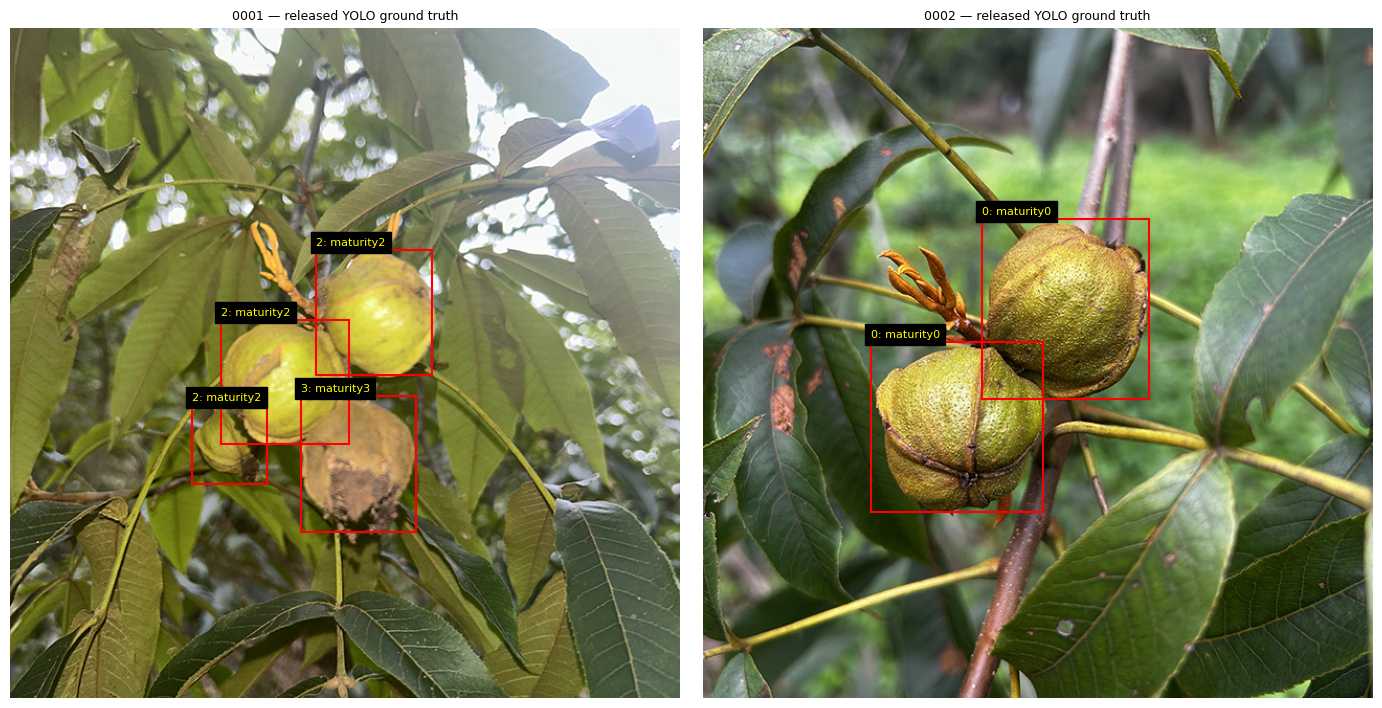

In [ ]:
import cv2
import matplotlib.pyplot as plt

def read_yolo(p):
    rows = []
    for line in Path(p).read_text().splitlines():
        parts = line.split()
        if len(parts) >= 5:
            rows.append((int(parts[0]), *map(float, parts[1:5])))
    return rows

id2name = dict(enumerate(CLASS_NAMES)) if CLASS_NAMES else AUTHOR_FALLBACK
print("id -> name mapping used for labels:", id2name)

rare = [s for s in targets if any(r[0] == 2 for r in read_yolo(yolo_files[s]))]
samples = [s for s in (rare[:1] + [s for s in targets if s not in set(rare)][:1]) if s]

fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 7))
axes = axes if len(samples) > 1 else [axes]
for ax, stem in zip(axes, samples):
    img_path = IMG_DIR / Path(scaled_by_stem[stem]).name
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    for cid, xc, yc, w, h in read_yolo(yolo_files[stem]):
        x1, y1 = (xc - w / 2) * img.shape[1], (yc - h / 2) * img.shape[0]
        ax.add_patch(plt.Rectangle((x1, y1), w * img.shape[1], h * img.shape[0],
                                   fill=False, edgecolor="red", linewidth=1.5))
        ax.text(x1, max(0, y1 - 4), f"{cid}: {id2name.get(cid, '?')}", color="yellow",
                fontsize=8, backgroundcolor="black")
    ax.set_title(f"{stem} — released YOLO ground truth", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

## 9. Run the authors' `image_qc.py` ROI screening (unmodified)

We execute the authors' script extracted from the verified `code.zip`, cross-checking it byte-identical against the pinned GitHub revision `8fde217`. Thresholds stay at the script defaults — Laplacian variance ≥ 100, Tenengrad ≥ 500, over-exposure ≤ 10 %, under-exposure ≤ 10 %, luminance std ≥ 25 — and the ROI is the YOLO box crop, exactly as authored.

**日本語:** 著者の `image_qc.py` を修正せず、既定の閾値のまま全 Scaled 画像に対して実行します。

In [ ]:
import subprocess, sys, hashlib

qc_scripts = sorted((EX / "code").rglob("image_qc.py"))
assert qc_scripts, "image_qc.py not found in extracted code.zip"
QC_SCRIPT = qc_scripts[0]
GH_RAW = ("https://raw.githubusercontent.com/JiaNanefu/Carya-Data-code/"
          "8fde217c7b69b0fef05e8c4d276525b78501a738/image_qc.py")
try:
    gh = urllib.request.urlopen(GH_RAW, timeout=60).read()
    same = hashlib.sha256(gh).hexdigest() == hashlib.sha256(QC_SCRIPT.read_bytes()).hexdigest()
    print("image_qc.py byte-identical to GitHub commit 8fde217:", same)
except Exception as e:
    print("GitHub cross-check skipped:", repr(e))

QC_OUT = BASE / "qc_out"
res = subprocess.run([sys.executable, str(QC_SCRIPT),
                      "--img_dir", str(IMG_DIR), "--label_dir", str(LBL_MIRROR),
                      "--out_dir", str(QC_OUT)])
print("exit code:", res.returncode)

image_qc.py byte-identical to GitHub commit 8fde217: True


exit code: 0


## 10. QC report summary

The `report.json` written by the authors' script: totals, flagged counts and the recorded thresholds, plus flagged boxes per class id.

**日本語:** 生成された `report.json` の要約(総数・不合格枠数・閾値・クラス別)を表示します。

In [ ]:
import json

rep = json.loads((QC_OUT / "report.json").read_text(encoding="utf-8"))
keys = ["处理图像总数", "标注框总数", "不合格标注框数", "涉及不合格图片数"]
print(json.dumps({k: rep[k] for k in keys if k in rep}, ensure_ascii=False, indent=2))
print("thresholds:", json.dumps(rep.get("质量阈值", {}), ensure_ascii=False))
per_class = {row["类别ID"]: row["不合格标注框数"] for row in rep.get("类别统计", [])}
print("flagged boxes per class id:", per_class)

{
  "处理图像总数": 1661,
  "标注框总数": 3203,
  "不合格标注框数": 204,
  "涉及不合格图片数": 159
}
thresholds: {"模糊_Laplacian最小值": 100.0, "模糊_Tenengrad最小值": 500.0, "过曝_最大比例": "10%", "欠曝_最大比例": "10%", "低对比度_亮度标准差最小值": 25.0}
flagged boxes per class id: {0: 12, 1: 21, 2: 36, 3: 68, 4: 67}


## 11. Comparison with paper-reported values

The paper's Technical Validation reports **203 flagged boxes**: *unknown 67, maturity3 67, maturity1 33, maturity2 36* (reference values recorded from the paper via PhenoPaper investigation run `…-4183239`). We compare the reproduced total and per-class counts wherever the released class mapping actually contains a matching name; unmatched paper rows are shown as `None` rather than guessed. The released `classes.txt` uses ids `maturity0…maturity3, unknown`, which is itself informative about the paper's naming.

**日本語:** 論文報告値(合計 203、クラス別 67/67/33/36)と再現値を比較します。対応するクラス名のみ照合し、推測はしません。

In [ ]:
import pandas as pd

PAPER_TOTAL = 203
PAPER_BY_NAME = {"unknown": 67, "maturity3": 67, "maturity1": 33, "maturity2": 36}

cmp_rows = [{"quantity": "flagged boxes (total)", "reproduced": rep.get("不合格标注框数"),
             "paper (reference)": PAPER_TOTAL}]
mapped = {id2name.get(cid, f"id{cid}"): v for cid, v in per_class.items()}
for name, ref in PAPER_BY_NAME.items():
    cmp_rows.append({"quantity": f"flagged boxes — {name}", "reproduced": mapped.get(name),
                     "paper (reference)": ref})
cmp_df = pd.DataFrame(cmp_rows)
print(cmp_df.to_string(index=False))
unmapped = [n for n in PAPER_BY_NAME if n not in mapped]
if unmapped:
    print("\nNOTE: the released mapping contains no id named", unmapped,
          "-> those paper rows are left unreproduced rather than guessed.")

                 quantity  reproduced  paper (reference)
    flagged boxes (total)         204                203
  flagged boxes — unknown          67                 67
flagged boxes — maturity3          68                 67
flagged boxes — maturity1          21                 33
flagged boxes — maturity2          36                 36


## 12. Cross-check against the authors' released QC output

The authors released their own QC result inside `code.zip` (`code/final_reason_analysis/`: `bad_quality_list.txt` + images). We compare our reproduced flagged-image list against theirs by file stem — an author-produced reference for the same screening, stronger than the paper's summary numbers alone. The authors' list contains Windows paths, so stems are taken after splitting on both `/` and `\` (verified in a prior run: POSIX `Path.stem` does not split backslashes).

**日本語:** 著者自身が公開している QC 結果(`final_reason_analysis`)と、本再現の不合格画像リストをファイル名(Windows パス区切りも処理)で照合します。

In [ ]:
import re

author_qc_list = sorted((EX / "code").rglob("bad_quality_list.txt"))
assert author_qc_list, "authors' released bad_quality_list.txt not found"

def stems_of(path):
    out = set()
    for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        if not line.strip():
            continue
        first = line.split("\t")[0].strip()
        out.add(re.split(r"[\\/]", first)[-1].rsplit(".", 1)[0])
    return out

author_stems = stems_of(author_qc_list[0])
ours_stems = stems_of(QC_OUT / "bad_quality_list.txt")
qc_overlap = author_stems & ours_stems
print(f"authors' released flagged images: {len(author_stems)} | reproduced: {len(ours_stems)}")
print(f"overlap: {len(qc_overlap)} | only in authors' list: {len(author_stems - ours_stems)} | only in ours: {len(ours_stems - author_stems)}")
if author_stems - ours_stems:
    print("authors-only examples:", sorted(author_stems - ours_stems)[:5])
if ours_stems - author_stems:
    print("ours-only examples:", sorted(ours_stems - author_stems)[:5])

authors' released flagged images: 158 | reproduced: 159
overlap: 158 | only in authors' list: 0 | only in ours: 1
ours-only examples: ['0104']


## 12. Annotation-agreement machinery (`check_yolo_annotations_agreement.py`)

The paper's double-blind check compares two **independent annotation rounds** (same box count, same class, IoU ≥ 0.9, Hungarian matching). If the public release contains only one annotation set, we run the authors' script as a clearly labeled **ADAPTED FORMAT-CONSISTENCY CHECK**: released YOLO labels (A) vs. YOLO labels derived from released VOC XMLs (B) via the authors' own `voc_to_yolo.py`. That validates the released converter + agreement machinery, **not** inter-annotator agreement. The run is bounded to 150 images to limit copying.

**日本語:** 独立ラベル 2 世代が未公開の場合、著者の `voc_to_yolo.py` で VOC→YOLO を作り、書式整合性チェックとして実行します(論文の二重ブラインド検証の再現ではありません)。

In [ ]:
import importlib.util

N_AGREE = 150
ag_stems = targets[:N_AGREE]
AG = BASE / "agreement"
AG_IMG, AG_A, AG_B, AG_XML = AG / "images", AG / "labels_a", AG / "labels_b", AG / "voc_xml"
for d in (AG_IMG, AG_A, AG_B, AG_XML):
    d.mkdir(parents=True, exist_ok=True)
for stem in ag_stems:
    fname = Path(scaled_by_stem[stem]).name
    shutil.copy2(IMG_DIR / fname, AG_IMG / fname)
    shutil.copy2(yolo_files[stem], AG_A / (stem + ".txt"))
    if stem in xml_files:
        shutil.copy2(xml_files[stem], AG_XML / (stem + ".xml"))

mode = None
if not list(AG_XML.glob("*.xml")):
    print("BLOCKER (this subsection only): no second annotation set (VOC or an independent round) "
          "is present in the public release; the paper's double-blind agreement check cannot be "
          "reproduced from public files. The QC and split subsections below are unaffected.")
else:
    v2y_path = sorted((EX / "code").rglob("voc_to_yolo.py"))[0]
    spec = importlib.util.spec_from_file_location("voc_to_yolo_author", v2y_path)
    v2y = importlib.util.module_from_spec(spec); spec.loader.exec_module(v2y)
    v2y.VOC_LABEL_DIR = str(AG_XML); v2y.YOLO_OUTPUT_DIR = str(AG_B)
    v2y.convert_voc_to_yolo()
    mode = "adapted_voc_vs_yolo (ADAPTED FORMAT-CONSISTENCY CHECK, not double-blind)"
    print("mode:", mode)

BLOCKER (this subsection only): no second annotation set (VOC or an independent round) is present in the public release; the paper's double-blind agreement check cannot be reproduced from public files. The QC and split subsections below are unaffected.


## 13. Run the authors' agreement script (IoU ≥ 0.9)

Executes `check_yolo_annotations_agreement.py` unmodified with its default threshold (passed explicitly) over the prepared subset, then prints the `statistics.json` summary it writes.

**日本語:** 著者の整合性チェックスクリプトを既定閾値(IoU ≥ 0.9)で実行し、統計を表示します。

In [ ]:
if mode:
    ag_script = sorted((EX / "code").rglob("check_yolo_annotations_agreement.py"))[0]
    AG_OUT = AG / "out"
    subprocess.run([sys.executable, str(ag_script),
                    "--labels_a", str(AG_A), "--labels_b", str(AG_B),
                    "--images_dir", str(AG_IMG), "--out_dir", str(AG_OUT),
                    "--iou_threshold", "0.9"])
    stats = json.loads((AG_OUT / "statistics.json").read_text(encoding="utf-8"))
    print(json.dumps(stats["stats"], indent=2))
else:
    print("agreement subsection skipped — see the blocker note above.")

agreement subsection skipped — see the blocker note above.


## 14. Reproduce the 6:2:2 stratified split logic (`stratified_split.py`)

The authors' script hard-codes Windows paths, so we reuse its **exact computation** — pools split by presence of rare class id 2, two `train_test_split` calls with `random_state=42` (test 0.2, then val 0.25 of the remainder), merge and shuffle — pointed at the released labels. This is a behavior-preserving path adaptation of `stratified_split.py` (lines 19–21 and 107–166 at commit `8fde217`).

**日本語:** `stratified_split.py` の分割ロジック(シード 42、6:2:2、希少クラス id 2)をパスだけ変えてそのまま再現します。

In [ ]:
import random
from sklearn.model_selection import train_test_split

RAREST_CLASS_ID, RANDOM_SEED = 2, 42
SPLIT_RATIOS = {"train": 0.6, "val": 0.2, "test": 0.2}

pool_rare, pool_common = [], []
for stem in sorted(targets):
    ids = {r[0] for r in read_yolo(yolo_files[stem])}
    (pool_rare if RAREST_CLASS_ID in ids else pool_common).append(stem)
print(f"rare pool: {len(pool_rare)} | common pool: {len(pool_common)}")

random.seed(RANDOM_SEED)
val_rel = SPLIT_RATIOS["val"] / (SPLIT_RATIOS["train"] + SPLIT_RATIOS["val"])
temp_rare, test_rare = train_test_split(pool_rare, test_size=SPLIT_RATIOS["test"], random_state=RANDOM_SEED)
train_rare, val_rare = train_test_split(temp_rare, test_size=val_rel, random_state=RANDOM_SEED)
temp_common, test_common = train_test_split(pool_common, test_size=SPLIT_RATIOS["test"], random_state=RANDOM_SEED)
train_common, val_common = train_test_split(temp_common, test_size=val_rel, random_state=RANDOM_SEED)

split = {"train": train_rare + train_common, "val": val_rare + val_common, "test": test_rare + test_common}
rare_in = {"train": train_rare, "val": val_rare, "test": test_rare}
for sp in ("train", "val", "test"):
    random.shuffle(split[sp])
    print(f"{sp}: {len(split[sp])} images (with rare class: {len(rare_in[sp])})")

rare pool: 830 | common pool: 831
train: 996 images (with rare class: 498)
val: 332 images (with rare class: 166)
test: 333 images (with rare class: 166)


## 15. Compare with the released train/val/test split

The released split membership lives in `labels.zip` (`labels/{train,val,test}` — the same split used for YOLO training), and the section-5 listing checks whether `CaryaData_YOLO/` also exists in the image archive. Overlap is exact only if the authors split exactly this label set with this seed and no post-QC filtering; any difference is reported honestly, including duplicate stems across released splits.

**日本語:** 公開分割(`labels.zip` の train/val/test、ファイル名のみ)と再現した分割の重なりを比較します。

In [ ]:
released = {}
for sp in ("train", "val", "test"):
    d = EX / "labels" / "labels" / sp
    released[sp] = {p.stem for p in d.glob("*.txt")} if d.is_dir() else set()
    alt = {Path(n).stem for n in names
           if f"/CaryaData_YOLO/{sp}/images/" in n and n.lower().endswith((".jpg", ".jpeg", ".png"))}
    if alt:
        released[sp] |= alt
        print(f"note: CaryaData_YOLO/{sp} also present in the image archive ({len(alt)} files)")
    if not released[sp]:
        print(f"WARNING: no released membership found for split '{sp}'")

split_rows = []
for sp in ("train", "val", "test"):
    inter = len(set(split[sp]) & released[sp])
    split_rows.append({"split": sp, "reproduced": len(split[sp]), "released": len(released[sp]),
                       "overlap": inter, "overlap % of released": round(100 * inter / max(1, len(released[sp])), 1)})
split_cmp = pd.DataFrame(split_rows)
print(split_cmp.to_string(index=False))
dup = (len(released["train"]) + len(released["val"]) + len(released["test"])) - len(set().union(*released.values()))
if dup:
    print(f"note: {dup} released stem(s) appear in more than one released split.")

split  reproduced  released  overlap  overlap % of released
train         996       996      606                   60.8
  val         332       334       62                   18.6
 test         333       334       73                   21.9
note: 2 released stem(s) appear in more than one released split.


## 16. Results summary and CSV export

A compact summary of all reproduced quantities; also saved to `/content/carya/results_summary.csv`.

**日本語:** 全結果の要約表を表示し、CSV に保存します。

In [ ]:
summary_rows = [
    {"section": "QC screening", "metric": "images processed", "value": rep.get("处理图像总数")},
    {"section": "QC screening", "metric": "boxes total", "value": rep.get("标注框总数")},
    {"section": "QC screening", "metric": "flagged boxes", "value": rep.get("不合格标注框数")},
    {"section": "QC screening", "metric": "paper reference flagged boxes", "value": PAPER_TOTAL},
    {"section": "QC screening", "metric": "flagged images vs authors' released list (overlap)", "value": len(qc_overlap)},
    {"section": "QC screening", "metric": "authors' released flagged images", "value": len(author_stems)},
]
if mode:
    summary_rows += [
        {"section": "agreement (adapted)", "metric": "images checked", "value": stats["stats"]["total_images"]},
        {"section": "agreement (adapted)", "metric": "qualified", "value": stats["stats"]["qualified_count"]},
        {"section": "agreement (adapted)", "metric": "rejected", "value": stats["stats"]["rejected_count"]},
    ]
summary_rows += [{"section": "stratified split", "metric": f"{r['split']} overlap with released", "value": r["overlap"]}
                 for r in split_rows]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(BASE / "results_summary.csv", index=False)
summary_df

,section,metric,value
0,QC screening,images processed,1661
1,QC screening,boxes total,3203
2,QC screening,flagged boxes,204
3,QC screening,paper reference flagged boxes,203
4,QC screening,flagged images vs authors' released list (over...,158
5,QC screening,authors' released flagged images,158
6,stratified split,train overlap with released,606
7,stratified split,val overlap with released,62
8,stratified split,test overlap with released,73


## 17. Interpretation, limitations, references

**Interpretation.** The executed outputs above report the reproduced quantities next to the paper-reported reference values. The QC screening runs the authors' unmodified script over the released Scaled images and mirrored labels, so its thresholds and metrics are the paper's own; the flagged-box total is compared with the paper's 203 and, more strongly, the flagged-image list with the authors' own released QC list. The agreement subsection is a released-format consistency check (unless two annotation rounds are found), not the paper's double-blind comparison. The split section re-executes the authors' exact seeded logic; overlap with the released `labels.zip` split also depends on which label set the authors split and any post-QC filtering they applied.

**Limitations.** Partial demonstration of the data-processing validation only; no YOLOv8n benchmark, no physical detachment experiment; one CPU pass, no dataset-wide retraining or benchmark claims. Where the paper's class naming differs from the released `classes.txt` (`maturity0…maturity3, unknown`), only matching names are compared.

**References.**
- Paper: *Scientific Data* 13:1047 (2026), DOI [10.1038/s41597-026-07407-9](https://doi.org/10.1038/s41597-026-07407-9).
- Code: GitHub [`JiaNanefu/Carya-Data-code`](https://github.com/JiaNanefu/Carya-Data-code) @ `8fde217c7b69b0fef05e8c4d276525b78501a738`; released as `code.zip` (md5 `1971606a…`), including the authors' `final_reason_analysis` QC output.
- Data: Zenodo record [18661602](https://zenodo.org/records/18661602) (paper-cited; `CaryaData.zip` md5 `e6daee8c…`) and [22054990](https://zenodo.org/records/22054990) (latest; `labels.zip` md5 `298da863…`).

**日本語:** 上記の実行結果を論文の参照値および著者公開の QC リストと比較してください。アノテーション整合性は公開ファイルによる書式整合チェックであり(2 世代が見つかった場合を除く)、論文の二重ブラインド検証そのものではありません。学習ベンチマークと物理実験は対象外です。